# MATRIX Testbed — Cross-Layer Latency Analysis

Combines two data sources into one comparable dataset:

1. **`middleware_latency.csv`** — produced by `middleware_latency.py`. Contains BOTH:
   - **Middleware <-> PLC** rows (Allen-Bradley Micro820 / EtherNet/IP, Schneider TM221 / Modbus TCP, Siemens S7-1200 / OPC UA)
   - **SCADA <-> Middleware** rows (OPC UA read / OPC UA write against the middleware's own OPC-UA server)
2. **Raw (unsummarised) `pcap_parser_v1.py` output** — the `df_results` DataFrame dumped via `.to_csv(...)` *before* `compute_statistics()` was applied. We filter this down to only the two **Inter-PLC** boundaries (S7-1200<->Micro820, TM221<->Micro820), since peer-to-peer PLC traffic can only be measured passively.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
# ============================================================
# CONFIG — update these paths to match your actual files
# ============================================================
MIDDLEWARE_LATENCY_CSV = r"..\data\scada_middleware_latency.csv"     # from middleware_latency.py
PCAP_RAW_RTT_CSV       = r"..\data\raw_latency_data.csv"            # your raw df_results.to_csv(...) dump
MIDDLEWARE_PLC_CSV = r"..\data\middleware_latency.csv"  # from middleware_plc_latency.py
# Boundary labels must match exactly what categorize_boundary() in
# pcap_parser_v1.py returns for the two Inter-PLC peer-to-peer links.
INTER_PLC_BOUNDARIES = [
    "S7-1200 <-> Micro820 (Modbus TCP)",
    "TM221 <-> Micro820 (Modbus TCP)",]


## 1. Load `middleware_latency.csv` (Middleware<->PLC and SCADA<->Middleware)

In [7]:
if not os.path.exists(MIDDLEWARE_LATENCY_CSV):
    raise FileNotFoundError(f"Could not find {MIDDLEWARE_LATENCY_CSV}")


#READ Middleware <-> SCADA latency CSV
scada_mw_df = pd.read_csv(MIDDLEWARE_LATENCY_CSV)
if not os.path.exists(MIDDLEWARE_PLC_CSV):
    raise FileNotFoundError(f"Could not find {MIDDLEWARE_PLC_CSV}")

#READ Middleware <-> PLC latency CSV
plc_mw_df = pd.read_csv(MIDDLEWARE_PLC_CSV)

#COMBINE both latency CSVs into a single dataframe for analysis
combined_df = pd.concat([scada_mw_df, plc_mw_df], ignore_index=True)
combined_df.columns = [c.strip() for c in combined_df.columns]
print(f"Loaded {len(combined_df)} rows from {MIDDLEWARE_LATENCY_CSV}")
print("\nDevices found:",combined_df["device"].unique())
print("Protocols found:", combined_df["protocol"].unique())
combined_df.head()

Loaded 2000 rows from ..\data\scada_middleware_latency.csv

Devices found: <StringArray>
['RPi Middleware<->SCADA', 'Allen-Bradley Micro820',        'Schneider TM221',
        'Siemens S7-1200']
Length: 4, dtype: str
Protocols found: <StringArray>
['OPC UA', 'EtherNet/IP', 'Modbus TCP']
Length: 3, dtype: str


,device,protocol,sample_index,latency_ms
0,RPi Middleware<->SCADA,OPC UA,0,8.8951
1,RPi Middleware<->SCADA,OPC UA,1,9.5382
2,RPi Middleware<->SCADA,OPC UA,2,5.6340
3,RPi Middleware<->SCADA,OPC UA,3,5.0111
4,RPi Middleware<->SCADA,OPC UA,4,4.9327


### Classify each row by communication layer

Rule: any device labelled `Middleware` is the SCADA<->Middleware OPC-UA link
(read or write against the middleware's own server); everything else is a
direct Middleware<->PLC link.

In [8]:
def classify_layer(device: str) -> str:
    if "middleware" in device.lower():
        return "SCADA <-> Middleware"
    return "Middleware <-> PLC"

combined_df["Layer"] = combined_df["device"].apply(classify_layer)
combined_df = combined_df.rename(columns={
    "device": "Boundary",
    "protocol": "Protocol",
    "latency_ms": "Latency_ms"
})[["Layer", "Boundary", "Protocol", "Latency_ms"]]

combined_df.head()


,Layer,Boundary,Protocol,Latency_ms
0,SCADA <-> Middleware,RPi Middleware<->SCADA,OPC UA,8.8951
1,SCADA <-> Middleware,RPi Middleware<->SCADA,OPC UA,9.5382
2,SCADA <-> Middleware,RPi Middleware<->SCADA,OPC UA,5.6340
3,SCADA <-> Middleware,RPi Middleware<->SCADA,OPC UA,5.0111
4,SCADA <-> Middleware,RPi Middleware<->SCADA,OPC UA,4.9327


## 2. Load raw pcap RTT data and extract Inter-PLC boundaries only

In [9]:
if not os.path.exists(PCAP_RAW_RTT_CSV):
    raise FileNotFoundError(f"Could not find {PCAP_RAW_RTT_CSV}")

pcap_df = pd.read_csv(PCAP_RAW_RTT_CSV)
pcap_df.columns = [c.strip() for c in pcap_df.columns]
print(f"Loaded {len(pcap_df)} total rows from {PCAP_RAW_RTT_CSV}")
print("\nBoundaries present in file:", pcap_df["Boundary"].unique())

inter_plc_df = pcap_df[pcap_df["Boundary"].isin(INTER_PLC_BOUNDARIES)].copy()
print(f"\n{len(inter_plc_df)} rows matched the Inter-PLC boundary filter")

inter_plc_df["Layer"] = "Inter-PLC"
inter_plc_df = inter_plc_df.rename(columns={"RTT_ms": "Latency_ms"})[
    ["Layer", "Boundary", "Protocol", "Latency_ms"]
]

inter_plc_df.head()


Loaded 121969 total rows from ..\data\raw_latency_data.csv

Boundaries present in file: <StringArray>
[     'Middleware <-> TM221 (Modbus TCP)',
        'TM221 <-> Micro820 (Modbus TCP)',
        'Middleware <-> S7-1200 (OPC UA)',
  'Middleware <-> Micro820 (EtherNet/IP)',
 'Ignition SCADA <-> Middleware (OPC UA)',
      'S7-1200 <-> Micro820 (Modbus TCP)']
Length: 6, dtype: str

90281 rows matched the Inter-PLC boundary filter


,Layer,Boundary,Protocol,Latency_ms
4,Inter-PLC,TM221 <-> Micro820 (Modbus TCP),Modbus TCP,3.465176
6,Inter-PLC,TM221 <-> Micro820 (Modbus TCP),Modbus TCP,2.221823
7,Inter-PLC,TM221 <-> Micro820 (Modbus TCP),Modbus TCP,3.168344
9,Inter-PLC,TM221 <-> Micro820 (Modbus TCP),Modbus TCP,191.426992
10,Inter-PLC,TM221 <-> Micro820 (Modbus TCP),Modbus TCP,4.114866


## 3. Combine into one unified dataset

In [10]:
combined_df = pd.concat([inter_plc_df, combined_df], ignore_index=True)
combined_df["Latency_ms"] = pd.to_numeric(combined_df["Latency_ms"], errors="coerce")
combined_df = combined_df.dropna(subset=["Latency_ms"])

print(f"Combined dataset: {len(combined_df)} rows across {combined_df['Layer'].nunique()} layers "
      f"and {combined_df['Boundary'].nunique()} boundaries")
combined_df.groupby(["Layer", "Boundary", "Protocol"]).size()


Combined dataset: 92281 rows across 3 layers and 6 boundaries


Layer                 Boundary                           Protocol   
Inter-PLC             S7-1200 <-> Micro820 (Modbus TCP)  Modbus TCP     78285
                      TM221 <-> Micro820 (Modbus TCP)    Modbus TCP     11996
Middleware <-> PLC    Allen-Bradley Micro820             EtherNet/IP      500
                      Schneider TM221                    Modbus TCP       500
                      Siemens S7-1200                    OPC UA           500
SCADA <-> Middleware  RPi Middleware<->SCADA             OPC UA           500
dtype: int64

## 4. Summary statistics per boundary

In [11]:
def compute_summary(df):
    stats_list = []
    grouped = df.groupby(["Layer", "Boundary", "Protocol"])
    for (layer, boundary, protocol), group in grouped:
        lat = group["Latency_ms"]
        stats_list.append({
            "Layer": layer,
            "Boundary": boundary,
            "Protocol": protocol,
            "N": len(lat),
            "Mean (ms)": np.mean(lat),
            "Std Dev (ms)": np.std(lat),
            "Min (ms)": np.min(lat),
            "Max (ms)": np.max(lat),
            "P95 (ms)": np.percentile(lat, 95),
            "P99 (ms)": np.percentile(lat, 99),
        })
    return pd.DataFrame(stats_list).sort_values(["Layer", "Boundary"]).reset_index(drop=True)

summary_df = compute_summary(combined_df)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print(summary_df.to_string(index=False))

               Layer                          Boundary    Protocol     N  Mean (ms)  Std Dev (ms)  Min (ms)  Max (ms)  P95 (ms)  P99 (ms)
           Inter-PLC S7-1200 <-> Micro820 (Modbus TCP)  Modbus TCP 78285      7.514         7.226     0.108   138.602    11.487    40.011
           Inter-PLC   TM221 <-> Micro820 (Modbus TCP)  Modbus TCP 11996     50.010        80.739     0.201   219.950   191.068   192.782
  Middleware <-> PLC            Allen-Bradley Micro820 EtherNet/IP   500      5.899         0.634     2.985    12.987     6.433     6.810
  Middleware <-> PLC                   Schneider TM221  Modbus TCP   500      2.020         0.193     1.642     3.611     2.297     2.711
  Middleware <-> PLC                   Siemens S7-1200      OPC UA   500     66.426        18.530    46.798   164.120   104.847   122.130
SCADA <-> Middleware            RPi Middleware<->SCADA      OPC UA   500      5.299         1.907     4.644    24.747     6.084    13.805


## 5. Cross-layer comparison plot (log scale — latencies span orders of magnitude)

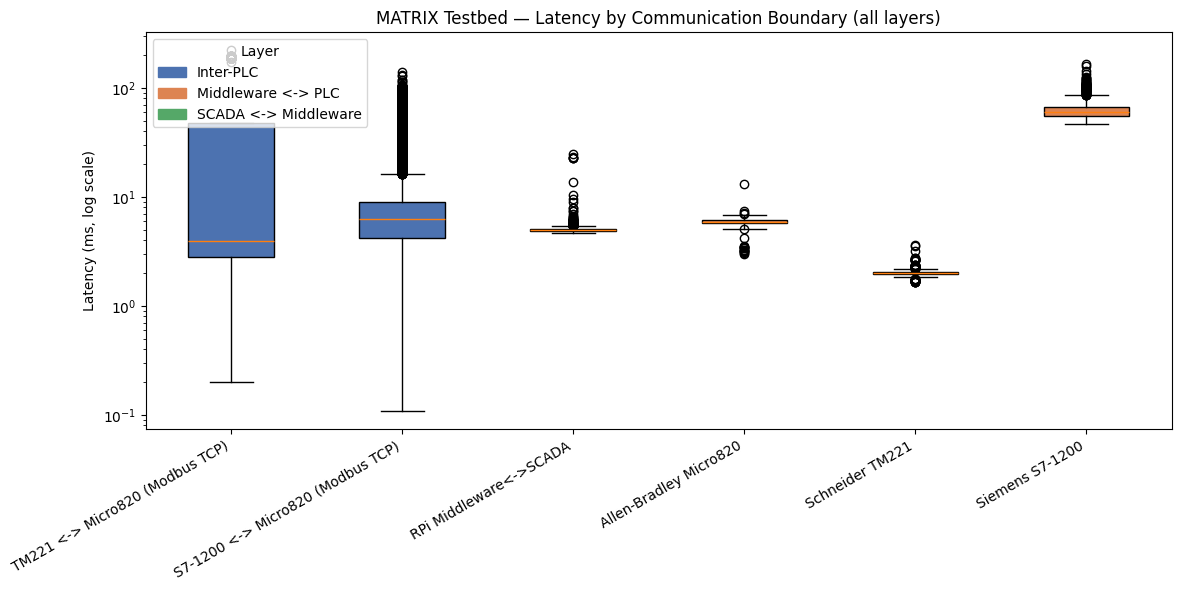

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

boundaries = combined_df["Boundary"].unique()
data_by_boundary = [combined_df[combined_df["Boundary"] == b]["Latency_ms"].values for b in boundaries]

bp = ax.boxplot(data_by_boundary, tick_labels=boundaries, showfliers=True, patch_artist=True)

layer_colors = {
    "Inter-PLC": "#4C72B0",
    "Middleware <-> PLC": "#DD8452",
    "SCADA <-> Middleware": "#55A868",
}
boundary_to_layer = combined_df.drop_duplicates("Boundary").set_index("Boundary")["Layer"].to_dict()
for patch, boundary in zip(bp["boxes"], boundaries):
    patch.set_facecolor(layer_colors.get(boundary_to_layer.get(boundary), "#CCCCCC"))

ax.set_yscale("log")
ax.set_ylabel("Latency (ms, log scale)")
ax.set_title("MATRIX Testbed — Latency by Communication Boundary (all layers)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# Legend for layer colors
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in layer_colors.values()]
ax.legend(handles, layer_colors.keys(), title="Layer", loc="upper left")

plt.tight_layout()
plt.savefig("cross_layer_latency_boxplot.png", dpi=200)
plt.show()


## 6. Save combined dataset

In [13]:
combined_df.to_csv(r"..\data\combined_latency_dataset.csv", index=False)
summary_df.to_csv(r"..\data\combined_latency_summary.csv", index=False)
print("Saved combined_latency_dataset.csv and combined_latency_summary.csv")

Saved combined_latency_dataset.csv and combined_latency_summary.csv
